In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
sales = np.array([
    100, 110, 115, 120, 130,
    128, 135, 140, 150, 155,
    160, 158, 165, 170, 180,
    178, 185, 190, 200, 210
])

df = pd.DataFrame({
    "day": np.arange(1, len(sales) + 1),
    "sales": sales
})

df

,day,sales
0,1,100
1,2,110
2,3,115
3,4,120
4,5,130
5,6,128
6,7,135
7,8,140
8,9,150
9,10,155


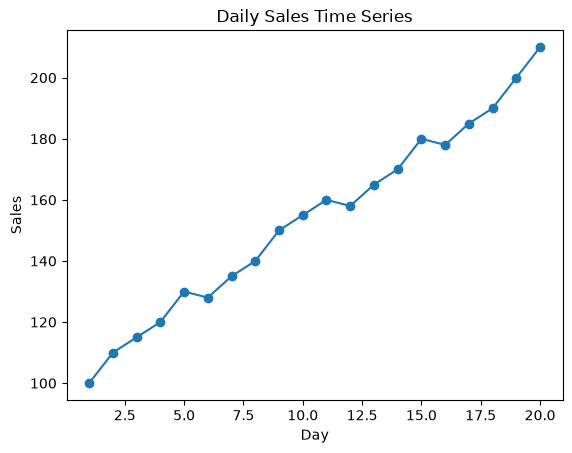

In [20]:
plt.plot(df["day"], df["sales"], marker="o")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.title("Daily Sales Time Series")
plt.show()

In [21]:
df["lag_1"] = df["sales"].shift(1)
df["lag_2"] = df["sales"].shift(2)
df["lag_3"] = df["sales"].shift(3)

df

,day,sales,lag_1,lag_2,lag_3
0,1,100,NaN,NaN,NaN
1,2,110,100.0,NaN,NaN
2,3,115,110.0,100.0,NaN
3,4,120,115.0,110.0,100.0
4,5,130,120.0,115.0,110.0
5,6,128,130.0,120.0,115.0
6,7,135,128.0,130.0,120.0
7,8,140,135.0,128.0,130.0
8,9,150,140.0,135.0,128.0
9,10,155,150.0,140.0,135.0


In [22]:
df_ml = df.dropna()

df_ml

,day,sales,lag_1,lag_2,lag_3
3,4,120,115.0,110.0,100.0
4,5,130,120.0,115.0,110.0
5,6,128,130.0,120.0,115.0
6,7,135,128.0,130.0,120.0
7,8,140,135.0,128.0,130.0
8,9,150,140.0,135.0,128.0
9,10,155,150.0,140.0,135.0
10,11,160,155.0,150.0,140.0
11,12,158,160.0,155.0,150.0
12,13,165,158.0,160.0,155.0


In [23]:
X = df_ml[["lag_1", "lag_2", "lag_3"]]
y = df_ml["sales"]

print(X)
print(y)

    lag_1  lag_2  lag_3
3   115.0  110.0  100.0
4   120.0  115.0  110.0
5   130.0  120.0  115.0
6   128.0  130.0  120.0
7   135.0  128.0  130.0
8   140.0  135.0  128.0
9   150.0  140.0  135.0
10  155.0  150.0  140.0
11  160.0  155.0  150.0
12  158.0  160.0  155.0
13  165.0  158.0  160.0
14  170.0  165.0  158.0
15  180.0  170.0  165.0
16  178.0  180.0  170.0
17  185.0  178.0  180.0
18  190.0  185.0  178.0
19  200.0  190.0  185.0
3     120
4     130
5     128
6     135
7     140
8     150
9     155
10    160
11    158
12    165
13    170
14    180
15    178
16    185
17    190
18    200
19    210
Name: sales, dtype: int64


In [24]:
split_index = int(len(df_ml) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("训练集大小：", X_train.shape)
print("测试集大小：", X_test.shape)

训练集大小： (13, 3)
测试集大小： (4, 3)


In [25]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [26]:
y_pred = model.predict(X_test)

print(y_pred)

[177.32 177.32 177.32 177.32]


In [27]:
result = pd.DataFrame({
    "true_sales": y_test.values,
    "pred_sales": y_pred
})

result

,true_sales,pred_sales
0,185,177.32
1,190,177.32
2,200,177.32
3,210,177.32


In [28]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 18.930000000000007
MSE: 450.5324000000003
RMSE: 21.225748514481186
R2: -3.8871311186440707


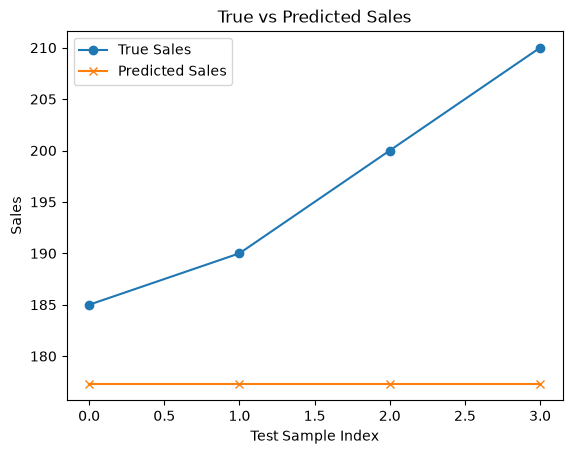

In [29]:
plt.plot(y_test.values, marker="o", label="True Sales")
plt.plot(y_pred, marker="x", label="Predicted Sales")

plt.xlabel("Test Sample Index")
plt.ylabel("Sales")
plt.title("True vs Predicted Sales")
plt.legend()
plt.show()

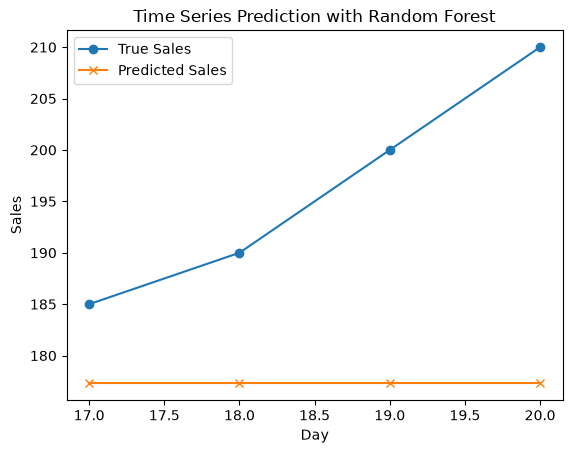

In [30]:
test_days = df_ml.iloc[split_index:]["day"]

plt.plot(test_days, y_test.values, marker="o", label="True Sales")
plt.plot(test_days, y_pred, marker="x", label="Predicted Sales")

plt.xlabel("Day")
plt.ylabel("Sales")
plt.title("Time Series Prediction with Random Forest")
plt.legend()
plt.show()

In [31]:
df.tail()

,day,sales,lag_1,lag_2,lag_3
15,16,178,180.0,170.0,165.0
16,17,185,178.0,180.0,170.0
17,18,190,185.0,178.0,180.0
18,19,200,190.0,185.0,178.0
19,20,210,200.0,190.0,185.0


In [32]:
last_3_days = df["sales"].iloc[-3:].values

last_3_days

array([190, 200, 210])

In [33]:
next_day_X = pd.DataFrame({
    "lag_1": [df["sales"].iloc[-1]],
    "lag_2": [df["sales"].iloc[-2]],
    "lag_3": [df["sales"].iloc[-3]]
})

next_day_X

,lag_1,lag_2,lag_3
0,210,200,190


In [34]:
next_day_pred = model.predict(next_day_X)

print("预测第 21 天销量：", next_day_pred[0])

预测第 21 天销量： 177.32


In [35]:
sales = np.array([
    100, 110, 115, 120, 130,
    128, 135, 140, 150, 155,
    160, 158, 165, 170, 180,
    178, 185, 190, 200, 210
])

df = pd.DataFrame({
    "day": np.arange(1, len(sales) + 1),
    "sales": sales
})

df

,day,sales
0,1,100
1,2,110
2,3,115
3,4,120
4,5,130
5,6,128
6,7,135
7,8,140
8,9,150
9,10,155


In [36]:
df["lag_1"] = df["sales"].shift(1)
df["lag_2"] = df["sales"].shift(2)
df["lag_3"] = df["sales"].shift(3)

df

,day,sales,lag_1,lag_2,lag_3
0,1,100,NaN,NaN,NaN
1,2,110,100.0,NaN,NaN
2,3,115,110.0,100.0,NaN
3,4,120,115.0,110.0,100.0
4,5,130,120.0,115.0,110.0
5,6,128,130.0,120.0,115.0
6,7,135,128.0,130.0,120.0
7,8,140,135.0,128.0,130.0
8,9,150,140.0,135.0,128.0
9,10,155,150.0,140.0,135.0


In [37]:
df["rolling_mean_3"] = df["sales"].shift(1).rolling(window=3).mean()
df["rolling_mean_5"] = df["sales"].shift(1).rolling(window=5).mean()

df

,day,sales,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_5
0,1,100,NaN,NaN,NaN,NaN,NaN
1,2,110,100.0,NaN,NaN,NaN,NaN
2,3,115,110.0,100.0,NaN,NaN,NaN
3,4,120,115.0,110.0,100.0,108.333333,NaN
4,5,130,120.0,115.0,110.0,115.000000,NaN
5,6,128,130.0,120.0,115.0,121.666667,115.0
6,7,135,128.0,130.0,120.0,126.000000,120.6
7,8,140,135.0,128.0,130.0,131.000000,125.6
8,9,150,140.0,135.0,128.0,134.333333,130.6
9,10,155,150.0,140.0,135.0,141.666667,136.6


In [38]:
df_ml = df.dropna()

df_ml

,day,sales,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_5
5,6,128,130.0,120.0,115.0,121.666667,115.0
6,7,135,128.0,130.0,120.0,126.000000,120.6
7,8,140,135.0,128.0,130.0,131.000000,125.6
8,9,150,140.0,135.0,128.0,134.333333,130.6
9,10,155,150.0,140.0,135.0,141.666667,136.6
10,11,160,155.0,150.0,140.0,148.333333,141.6
11,12,158,160.0,155.0,150.0,155.000000,148.0
12,13,165,158.0,160.0,155.0,157.666667,152.6
13,14,170,165.0,158.0,160.0,161.000000,157.6
14,15,180,170.0,165.0,158.0,164.333333,161.6


In [39]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "rolling_mean_5"
]

X = df_ml[features]
y = df_ml["sales"]

X.head()

,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_5
5,130.0,120.0,115.0,121.666667,115.0
6,128.0,130.0,120.0,126.000000,120.6
7,135.0,128.0,130.0,131.000000,125.6
8,140.0,135.0,128.0,134.333333,130.6
9,150.0,140.0,135.0,141.666667,136.6


In [40]:
split_index = int(len(df_ml) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("训练集大小：", X_train.shape)
print("测试集大小：", X_test.shape)

训练集大小： (12, 5)
测试集大小： (3, 5)


In [41]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [42]:
y_pred = model.predict(X_test)

result = pd.DataFrame({
    "day": df_ml.iloc[split_index:]["day"].values,
    "true_sales": y_test.values,
    "pred_sales": y_pred
})

result

,day,true_sales,pred_sales
0,18,190,182.37
1,19,200,182.37
2,20,210,182.37


In [43]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 17.629999999999995
MSE: 377.4835666666665
RMSE: 19.428936323604194
R2: -4.662253499999997


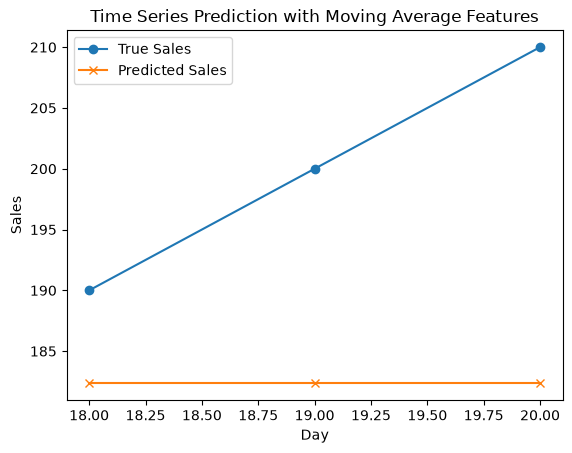

In [44]:
test_days = df_ml.iloc[split_index:]["day"]

plt.plot(test_days, y_test.values, marker="o", label="True Sales")
plt.plot(test_days, y_pred, marker="x", label="Predicted Sales")

plt.xlabel("Day")
plt.ylabel("Sales")
plt.title("Time Series Prediction with Moving Average Features")
plt.legend()
plt.show()

In [45]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
3,rolling_mean_3,0.229041
4,rolling_mean_5,0.219924
0,lag_1,0.215235
1,lag_2,0.189566
2,lag_3,0.146233


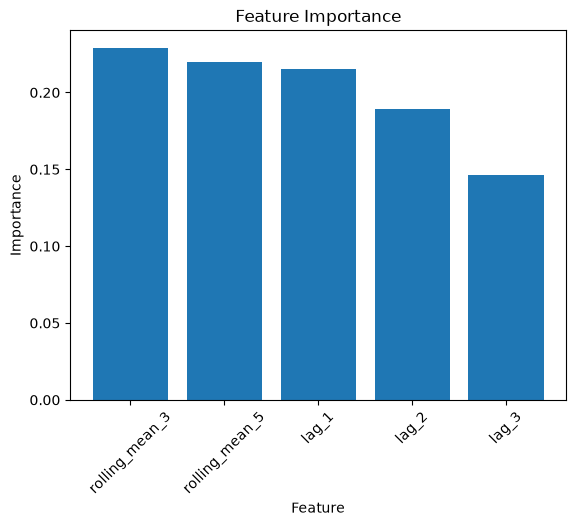

In [46]:
plt.bar(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [61]:
sales = np.array([
    100, 110, 115, 120, 130,
    128, 135, 140, 150, 155,
    160, 158, 165, 170, 180,
    178, 185, 190, 200, 210
])

df = pd.DataFrame({
    "day": np.arange(1, len(sales) + 1),
    "sales": sales
})

df

,day,sales
0,1,100
1,2,110
2,3,115
3,4,120
4,5,130
5,6,128
6,7,135
7,8,140
8,9,150
9,10,155


In [62]:
df["lag_1"] = df["sales"].shift(1)
df["lag_2"] = df["sales"].shift(2)
df["lag_3"] = df["sales"].shift(3)

df

,day,sales,lag_1,lag_2,lag_3
0,1,100,NaN,NaN,NaN
1,2,110,100.0,NaN,NaN
2,3,115,110.0,100.0,NaN
3,4,120,115.0,110.0,100.0
4,5,130,120.0,115.0,110.0
5,6,128,130.0,120.0,115.0
6,7,135,128.0,130.0,120.0
7,8,140,135.0,128.0,130.0
8,9,150,140.0,135.0,128.0
9,10,155,150.0,140.0,135.0


In [63]:
df["rolling_mean_3"] = df["sales"].shift(1).rolling(window=3).mean()
df["rolling_mean_5"] = df["sales"].shift(1).rolling(window=5).mean()

df

,day,sales,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_5
0,1,100,NaN,NaN,NaN,NaN,NaN
1,2,110,100.0,NaN,NaN,NaN,NaN
2,3,115,110.0,100.0,NaN,NaN,NaN
3,4,120,115.0,110.0,100.0,108.333333,NaN
4,5,130,120.0,115.0,110.0,115.000000,NaN
5,6,128,130.0,120.0,115.0,121.666667,115.0
6,7,135,128.0,130.0,120.0,126.000000,120.6
7,8,140,135.0,128.0,130.0,131.000000,125.6
8,9,150,140.0,135.0,128.0,134.333333,130.6
9,10,155,150.0,140.0,135.0,141.666667,136.6


In [64]:
df_ml = df.dropna()

df_ml

,day,sales,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_5
5,6,128,130.0,120.0,115.0,121.666667,115.0
6,7,135,128.0,130.0,120.0,126.000000,120.6
7,8,140,135.0,128.0,130.0,131.000000,125.6
8,9,150,140.0,135.0,128.0,134.333333,130.6
9,10,155,150.0,140.0,135.0,141.666667,136.6
10,11,160,155.0,150.0,140.0,148.333333,141.6
11,12,158,160.0,155.0,150.0,155.000000,148.0
12,13,165,158.0,160.0,155.0,157.666667,152.6
13,14,170,165.0,158.0,160.0,161.000000,157.6
14,15,180,170.0,165.0,158.0,164.333333,161.6


In [65]:
features = [
    "day",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "rolling_mean_5"
]

X = df_ml[features]
y = df_ml["sales"]

X.head()

,day,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_5
5,6,130.0,120.0,115.0,121.666667,115.0
6,7,128.0,130.0,120.0,126.000000,120.6
7,8,135.0,128.0,130.0,131.000000,125.6
8,9,140.0,135.0,128.0,134.333333,130.6
9,10,150.0,140.0,135.0,141.666667,136.6


In [66]:
split_index = int(len(df_ml) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("训练集大小：", X_train.shape)
print("测试集大小：", X_test.shape)

训练集大小： (12, 6)
测试集大小： (3, 6)


In [67]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [68]:
y_pred = model.predict(X_test)

result = pd.DataFrame({
    "day": df_ml.iloc[split_index:]["day"].values,
    "true_sales": y_test.values,
    "pred_sales": y_pred
})

result

,day,true_sales,pred_sales
0,18,190,182.36
1,19,200,182.36
2,20,210,182.36


In [69]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 17.639999999999986
MSE: 377.8362666666662
RMSE: 19.438010872171724
R2: -4.667543999999992


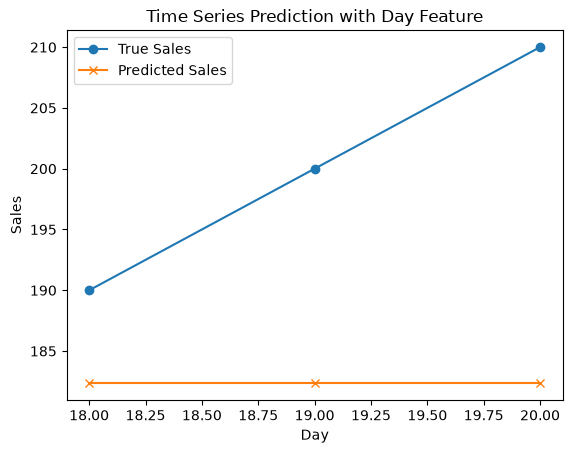

In [70]:
test_days = df_ml.iloc[split_index:]["day"]

plt.plot(test_days, y_test.values, marker="o", label="True Sales")
plt.plot(test_days, y_pred, marker="x", label="Predicted Sales")

plt.xlabel("Day")
plt.ylabel("Sales")
plt.title("Time Series Prediction with Day Feature")
plt.legend()
plt.show()

In [71]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
0,day,0.197367
4,rolling_mean_3,0.188712
5,rolling_mean_5,0.173570
1,lag_1,0.154221
3,lag_3,0.148765
2,lag_2,0.137366


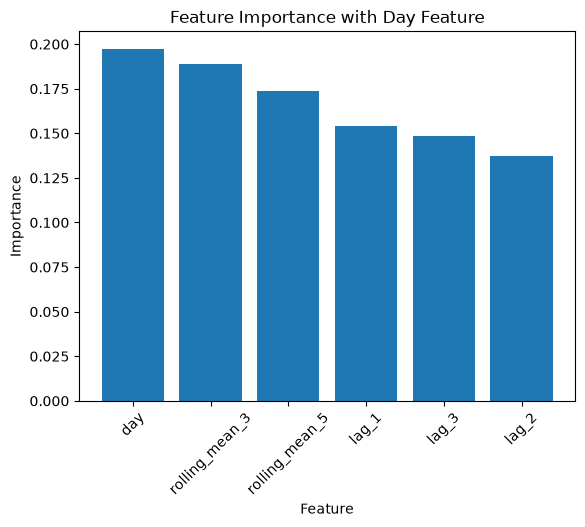

In [72]:
plt.bar(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance with Day Feature")
plt.xticks(rotation=45)
plt.show()

In [73]:
next_day_X = pd.DataFrame({
    "day": [21],
    "lag_1": [df["sales"].iloc[-1]],
    "lag_2": [df["sales"].iloc[-2]],
    "lag_3": [df["sales"].iloc[-3]],
    "rolling_mean_3": [df["sales"].iloc[-3:].mean()],
    "rolling_mean_5": [df["sales"].iloc[-5:].mean()]
})

next_day_X

,day,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_5
0,21,210,200,190,200.0,192.6


In [74]:
next_day_pred = model.predict(next_day_X)

print("预测第 21 天销量：", next_day_pred[0])

预测第 21 天销量： 182.36


In [75]:
sales = np.array([
    100, 110, 115, 120, 130,
    128, 135, 140, 150, 155,
    160, 158, 165, 170, 180,
    178, 185, 190, 200, 210
])

sales

array([100, 110, 115, 120, 130, 128, 135, 140, 150, 155, 160, 158, 165,
       170, 180, 178, 185, 190, 200, 210])

In [76]:
def create_sliding_window(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)

In [77]:
window_size = 3

X, y = create_sliding_window(sales, window_size)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("X 前 5 行：")
print(X[:5])

print("y 前 5 个：")
print(y[:5])

X shape: (17, 3)
y shape: (17,)
X 前 5 行：
[[100 110 115]
 [110 115 120]
 [115 120 130]
 [120 130 128]
 [130 128 135]]
y 前 5 个：
[120 130 128 135 140]


In [78]:
df_window = pd.DataFrame(
    X,
    columns=["t-3", "t-2", "t-1"]
)

df_window["target"] = y

df_window.head()

,t-3,t-2,t-1,target
0,100,110,115,120
1,110,115,120,130
2,115,120,130,128
3,120,130,128,135
4,130,128,135,140


In [79]:
split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("训练集大小：", X_train.shape)
print("测试集大小：", X_test.shape)

训练集大小： (13, 3)
测试集大小： (4, 3)


In [80]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [81]:
y_pred = model.predict(X_test)

result = pd.DataFrame({
    "true_sales": y_test,
    "pred_sales": y_pred
})

result

,true_sales,pred_sales
0,185,177.02
1,190,177.02
2,200,177.02
3,210,177.02


In [82]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 19.22999999999999
MSE: 461.9803999999996
RMSE: 21.49372931810577
R2: -4.011312813559317


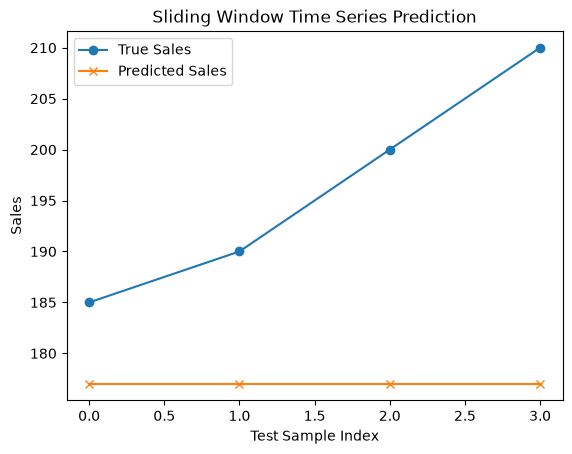

In [83]:
plt.plot(y_test, marker="o", label="True Sales")
plt.plot(y_pred, marker="x", label="Predicted Sales")

plt.xlabel("Test Sample Index")
plt.ylabel("Sales")
plt.title("Sliding Window Time Series Prediction")
plt.legend()
plt.show()

In [84]:
last_window = sales[-window_size:]

last_window

array([190, 200, 210])

In [85]:
next_X = last_window.reshape(1, -1)

next_X

array([[190, 200, 210]])

In [86]:
next_pred = model.predict(next_X)

print("预测第 21 天销量：", next_pred[0])

预测第 21 天销量： 177.02


In [87]:
window_sizes = [2, 3, 5, 7]

for window_size in window_sizes:
    X, y = create_sliding_window(sales, window_size)

    split_index = int(len(X) * 0.8)

    X_train = X[:split_index]
    X_test = X[split_index:]

    y_train = y[:split_index]
    y_test = y[split_index:]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"window_size={window_size}, MAE={mae:.2f}, RMSE={rmse:.2f}")

window_size=2, MAE=18.77, RMSE=21.08
window_size=3, MAE=19.23, RMSE=21.49
window_size=5, MAE=17.86, RMSE=19.64
window_size=7, MAE=17.91, RMSE=19.68


In [88]:
data = {
    "day": np.arange(1, 31),

    "price": [
        10, 10, 10, 9, 9,
        10, 10, 9, 9, 8,
        10, 10, 9, 9, 8,
        10, 10, 9, 9, 8,
        10, 9, 9, 8, 8,
        10, 9, 9, 8, 8
    ],

    "ad_spend": [
        100, 120, 110, 150, 160,
        130, 140, 170, 180, 200,
        150, 160, 180, 190, 220,
        170, 180, 200, 210, 240,
        190, 210, 220, 250, 260,
        220, 240, 250, 280, 300
    ],

    "is_holiday": [
        0, 0, 0, 1, 1,
        0, 0, 0, 1, 1,
        0, 0, 0, 1, 1,
        0, 0, 0, 1, 1,
        0, 0, 0, 1, 1,
        0, 0, 0, 1, 1
    ],

    "visits": [
        1000, 1050, 1080, 1300, 1350,
        1120, 1180, 1250, 1450, 1550,
        1200, 1250, 1320, 1500, 1650,
        1300, 1380, 1450, 1600, 1750,
        1400, 1500, 1580, 1800, 1900,
        1550, 1650, 1720, 1950, 2100
    ],

    "sales": [
        100, 108, 112, 135, 142,
        118, 125, 138, 155, 170,
        130, 138, 150, 168, 185,
        145, 155, 168, 188, 205,
        160, 178, 185, 215, 230,
        180, 198, 210, 245, 260
    ]
}

df = pd.DataFrame(data)

df.head()

,day,price,ad_spend,is_holiday,visits,sales
0,1,10,100,0,1000,100
1,2,10,120,0,1050,108
2,3,10,110,0,1080,112
3,4,9,150,1,1300,135
4,5,9,160,1,1350,142


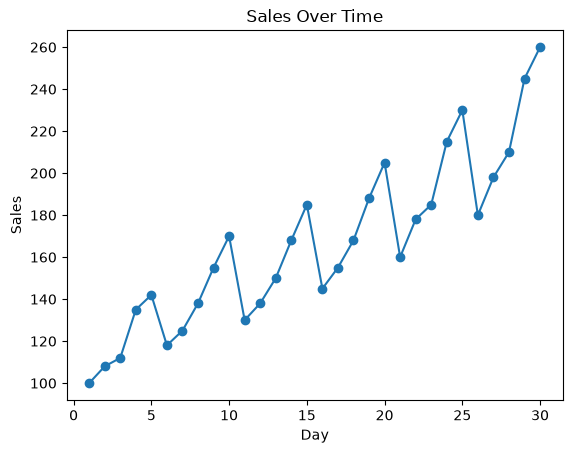

In [89]:
plt.plot(df["day"], df["sales"], marker="o")

plt.xlabel("Day")
plt.ylabel("Sales")
plt.title("Sales Over Time")
plt.show()

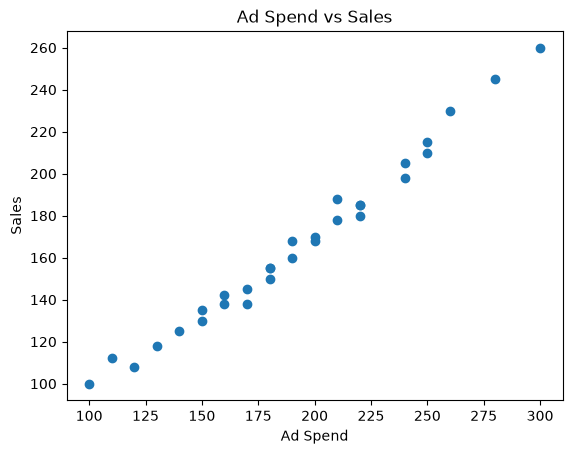

In [90]:
plt.scatter(df["ad_spend"], df["sales"])

plt.xlabel("Ad Spend")
plt.ylabel("Sales")
plt.title("Ad Spend vs Sales")
plt.show()

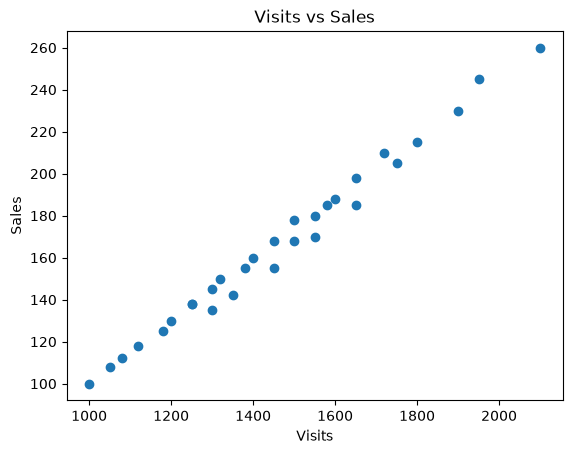

In [91]:
plt.scatter(df["visits"], df["sales"])

plt.xlabel("Visits")
plt.ylabel("Sales")
plt.title("Visits vs Sales")
plt.show()

In [92]:
df["sales_lag_1"] = df["sales"].shift(1)
df["sales_lag_2"] = df["sales"].shift(2)
df["sales_lag_3"] = df["sales"].shift(3)

df["visits_lag_1"] = df["visits"].shift(1)

df["sales_rolling_mean_3"] = df["sales"].shift(1).rolling(window=3).mean()

df.head(10)

,day,price,ad_spend,is_holiday,visits,sales,sales_lag_1,sales_lag_2,sales_lag_3,visits_lag_1,sales_rolling_mean_3
0,1,10,100,0,1000,100,NaN,NaN,NaN,NaN,NaN
1,2,10,120,0,1050,108,100.0,NaN,NaN,1000.0,NaN
2,3,10,110,0,1080,112,108.0,100.0,NaN,1050.0,NaN
3,4,9,150,1,1300,135,112.0,108.0,100.0,1080.0,106.666667
4,5,9,160,1,1350,142,135.0,112.0,108.0,1300.0,118.333333
5,6,10,130,0,1120,118,142.0,135.0,112.0,1350.0,129.666667
6,7,10,140,0,1180,125,118.0,142.0,135.0,1120.0,131.666667
7,8,9,170,0,1250,138,125.0,118.0,142.0,1180.0,128.333333
8,9,9,180,1,1450,155,138.0,125.0,118.0,1250.0,127.000000
9,10,8,200,1,1550,170,155.0,138.0,125.0,1450.0,139.333333


In [93]:
df_ml = df.dropna()

df_ml.head()

,day,price,ad_spend,is_holiday,visits,sales,sales_lag_1,sales_lag_2,sales_lag_3,visits_lag_1,sales_rolling_mean_3
3,4,9,150,1,1300,135,112.0,108.0,100.0,1080.0,106.666667
4,5,9,160,1,1350,142,135.0,112.0,108.0,1300.0,118.333333
5,6,10,130,0,1120,118,142.0,135.0,112.0,1350.0,129.666667
6,7,10,140,0,1180,125,118.0,142.0,135.0,1120.0,131.666667
7,8,9,170,0,1250,138,125.0,118.0,142.0,1180.0,128.333333


In [94]:
features = [
    "day",
    "price",
    "ad_spend",
    "is_holiday",
    "sales_lag_1",
    "sales_lag_2",
    "sales_lag_3",
    "visits_lag_1",
    "sales_rolling_mean_3"
]

X = df_ml[features]
y = df_ml["sales"]

X.head()

,day,price,ad_spend,is_holiday,sales_lag_1,sales_lag_2,sales_lag_3,visits_lag_1,sales_rolling_mean_3
3,4,9,150,1,112.0,108.0,100.0,1080.0,106.666667
4,5,9,160,1,135.0,112.0,108.0,1300.0,118.333333
5,6,10,130,0,142.0,135.0,112.0,1350.0,129.666667
6,7,10,140,0,118.0,142.0,135.0,1120.0,131.666667
7,8,9,170,0,125.0,118.0,142.0,1180.0,128.333333


In [95]:
split_index = int(len(df_ml) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("训练集大小：", X_train.shape)
print("测试集大小：", X_test.shape)

训练集大小： (21, 9)
测试集大小： (6, 9)


In [96]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [97]:
y_pred = model.predict(X_test)

result = pd.DataFrame({
    "day": df_ml.iloc[split_index:]["day"].values,
    "true_sales": y_test.values,
    "pred_sales": y_pred
})

result

,day,true_sales,pred_sales
0,25,230,207.355
1,26,180,197.975
2,27,198,201.950
3,28,210,206.065
4,29,245,207.355
5,30,260,207.205


In [98]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 23.1575
MSE: 845.2402374999998
RMSE: 29.073015624458357
R2: -0.12511179700499153


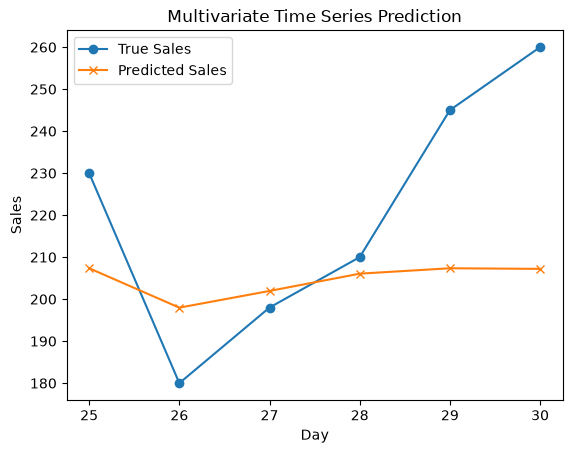

In [99]:
test_days = df_ml.iloc[split_index:]["day"]

plt.plot(test_days, y_test.values, marker="o", label="True Sales")
plt.plot(test_days, y_pred, marker="x", label="Predicted Sales")

plt.xlabel("Day")
plt.ylabel("Sales")
plt.title("Multivariate Time Series Prediction")
plt.legend()
plt.show()

In [100]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
2,ad_spend,0.837401
4,sales_lag_1,0.052678
0,day,0.035212
7,visits_lag_1,0.034708
5,sales_lag_2,0.015618
8,sales_rolling_mean_3,0.008348
1,price,0.007341
6,sales_lag_3,0.006936
3,is_holiday,0.001760


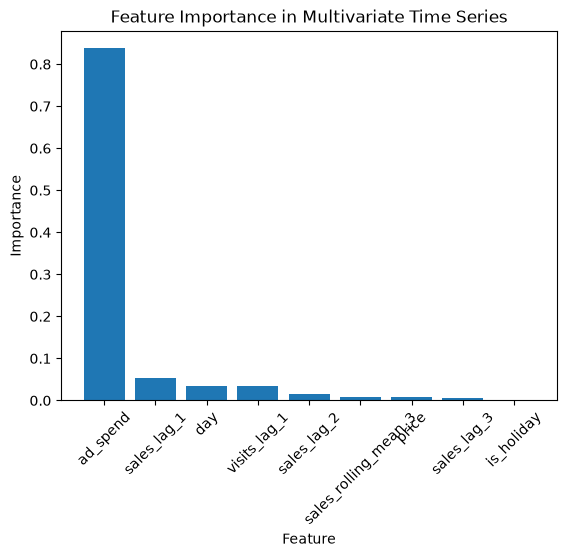

In [101]:
plt.bar(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Multivariate Time Series")
plt.xticks(rotation=45)
plt.show()

In [102]:
next_day_X = pd.DataFrame({
    "day": [31],
    "price": [8],
    "ad_spend": [320],
    "is_holiday": [1],

    "sales_lag_1": [df["sales"].iloc[-1]],
    "sales_lag_2": [df["sales"].iloc[-2]],
    "sales_lag_3": [df["sales"].iloc[-3]],

    "visits_lag_1": [df["visits"].iloc[-1]],

    "sales_rolling_mean_3": [df["sales"].iloc[-3:].mean()]
})

next_day_X

,day,price,ad_spend,is_holiday,sales_lag_1,sales_lag_2,sales_lag_3,visits_lag_1,sales_rolling_mean_3
0,31,8,320,1,260,245,210,2100,238.333333


In [103]:
next_day_pred = model.predict(next_day_X)

print("预测第 31 天销量：", next_day_pred[0])

预测第 31 天销量： 207.205


In [104]:
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [105]:
data = {
    "day": np.arange(1, 31),

    "price": [
        10, 10, 10, 9, 9,
        10, 10, 9, 9, 8,
        10, 10, 9, 9, 8,
        10, 10, 9, 9, 8,
        10, 9, 9, 8, 8,
        10, 9, 9, 8, 8
    ],

    "ad_spend": [
        100, 120, 110, 150, 160,
        130, 140, 170, 180, 200,
        150, 160, 180, 190, 220,
        170, 180, 200, 210, 240,
        190, 210, 220, 250, 260,
        220, 240, 250, 280, 300
    ],

    "is_holiday": [
        0, 0, 0, 1, 1,
        0, 0, 0, 1, 1,
        0, 0, 0, 1, 1,
        0, 0, 0, 1, 1,
        0, 0, 0, 1, 1,
        0, 0, 0, 1, 1
    ],

    "visits": [
        1000, 1050, 1080, 1300, 1350,
        1120, 1180, 1250, 1450, 1550,
        1200, 1250, 1320, 1500, 1650,
        1300, 1380, 1450, 1600, 1750,
        1400, 1500, 1580, 1800, 1900,
        1550, 1650, 1720, 1950, 2100
    ],

    "sales": [
        100, 108, 112, 135, 142,
        118, 125, 138, 155, 170,
        130, 138, 150, 168, 185,
        145, 155, 168, 188, 205,
        160, 178, 185, 215, 230,
        180, 198, 210, 245, 260
    ]
}

df = pd.DataFrame(data)

df.head()

,day,price,ad_spend,is_holiday,visits,sales
0,1,10,100,0,1000,100
1,2,10,120,0,1050,108
2,3,10,110,0,1080,112
3,4,9,150,1,1300,135
4,5,9,160,1,1350,142


In [106]:
df["sales_lag_1"] = df["sales"].shift(1)
df["sales_lag_2"] = df["sales"].shift(2)
df["sales_lag_3"] = df["sales"].shift(3)

df["visits_lag_1"] = df["visits"].shift(1)

df["sales_rolling_mean_3"] = df["sales"].shift(1).rolling(window=3).mean()

df.head(10)

,day,price,ad_spend,is_holiday,visits,sales,sales_lag_1,sales_lag_2,sales_lag_3,visits_lag_1,sales_rolling_mean_3
0,1,10,100,0,1000,100,NaN,NaN,NaN,NaN,NaN
1,2,10,120,0,1050,108,100.0,NaN,NaN,1000.0,NaN
2,3,10,110,0,1080,112,108.0,100.0,NaN,1050.0,NaN
3,4,9,150,1,1300,135,112.0,108.0,100.0,1080.0,106.666667
4,5,9,160,1,1350,142,135.0,112.0,108.0,1300.0,118.333333
5,6,10,130,0,1120,118,142.0,135.0,112.0,1350.0,129.666667
6,7,10,140,0,1180,125,118.0,142.0,135.0,1120.0,131.666667
7,8,9,170,0,1250,138,125.0,118.0,142.0,1180.0,128.333333
8,9,9,180,1,1450,155,138.0,125.0,118.0,1250.0,127.000000
9,10,8,200,1,1550,170,155.0,138.0,125.0,1450.0,139.333333


In [107]:
df_ml = df.dropna()

df_ml.head()

,day,price,ad_spend,is_holiday,visits,sales,sales_lag_1,sales_lag_2,sales_lag_3,visits_lag_1,sales_rolling_mean_3
3,4,9,150,1,1300,135,112.0,108.0,100.0,1080.0,106.666667
4,5,9,160,1,1350,142,135.0,112.0,108.0,1300.0,118.333333
5,6,10,130,0,1120,118,142.0,135.0,112.0,1350.0,129.666667
6,7,10,140,0,1180,125,118.0,142.0,135.0,1120.0,131.666667
7,8,9,170,0,1250,138,125.0,118.0,142.0,1180.0,128.333333


In [108]:
features = [
    "day",
    "price",
    "ad_spend",
    "is_holiday",
    "sales_lag_1",
    "sales_lag_2",
    "sales_lag_3",
    "visits_lag_1",
    "sales_rolling_mean_3"
]

X = df_ml[features]
y = df_ml["sales"]

X.head()

,day,price,ad_spend,is_holiday,sales_lag_1,sales_lag_2,sales_lag_3,visits_lag_1,sales_rolling_mean_3
3,4,9,150,1,112.0,108.0,100.0,1080.0,106.666667
4,5,9,160,1,135.0,112.0,108.0,1300.0,118.333333
5,6,10,130,0,142.0,135.0,112.0,1350.0,129.666667
6,7,10,140,0,118.0,142.0,135.0,1120.0,131.666667
7,8,9,170,0,125.0,118.0,142.0,1180.0,128.333333


In [109]:
split_index = int(len(df_ml) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("训练集大小：", X_train.shape)
print("测试集大小：", X_test.shape)

训练集大小： (21, 9)
测试集大小： (6, 9)


In [110]:
def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"模型：{model_name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-" * 30)

    return {
        "model": model_name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "pred": y_pred
    }

In [111]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_result = evaluate_model(
    "Random Forest",
    rf_model,
    X_train,
    y_train,
    X_test,
    y_test
)

模型：Random Forest
MAE: 23.1575
RMSE: 29.073015624458357
R2: -0.12511179700499153
------------------------------


In [112]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_result = evaluate_model(
    "XGBoost",
    xgb_model,
    X_train,
    y_train,
    X_test,
    y_test
)

模型：XGBoost
MAE: 20.800153732299805
RMSE: 25.124961131810732
R2: 0.15971559286117554
------------------------------


In [113]:
lgbm_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbose=-1
)

lgbm_result = evaluate_model(
    "LightGBM",
    lgbm_model,
    X_train,
    y_train,
    X_test,
    y_test
)

模型：LightGBM
MAE: 60.83333333333335
RMSE: 66.72289295619942
R2: -4.926049177297099
------------------------------


In [114]:
compare_df = pd.DataFrame([
    {
        "model": rf_result["model"],
        "MAE": rf_result["mae"],
        "RMSE": rf_result["rmse"],
        "R2": rf_result["r2"]
    },
    {
        "model": xgb_result["model"],
        "MAE": xgb_result["mae"],
        "RMSE": xgb_result["rmse"],
        "R2": xgb_result["r2"]
    },
    {
        "model": lgbm_result["model"],
        "MAE": lgbm_result["mae"],
        "RMSE": lgbm_result["rmse"],
        "R2": lgbm_result["r2"]
    }
])

compare_df

,model,MAE,RMSE,R2
0,Random Forest,23.157500,29.073016,-0.125112
1,XGBoost,20.800154,25.124961,0.159716
2,LightGBM,60.833333,66.722893,-4.926049


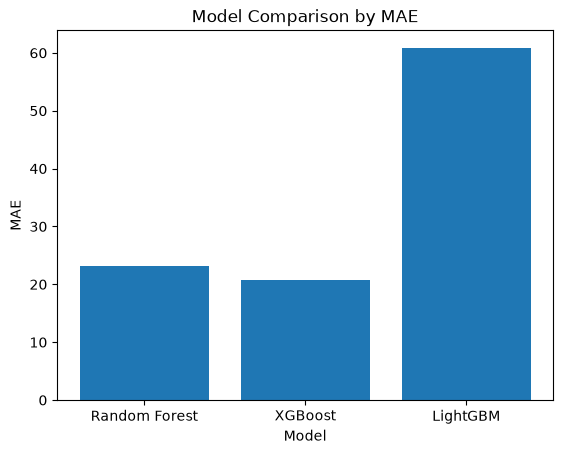

In [115]:
plt.bar(compare_df["model"], compare_df["MAE"])

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Comparison by MAE")
plt.show()

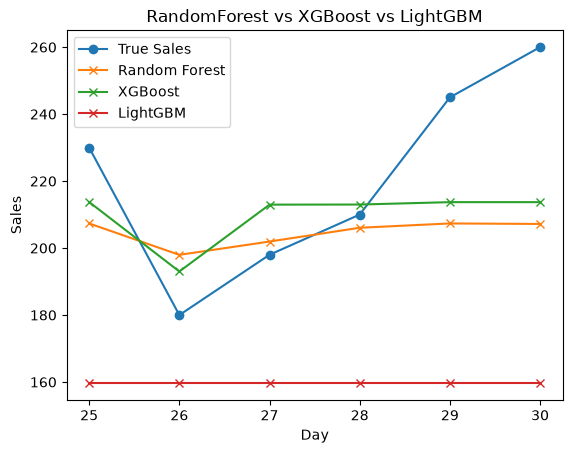

In [116]:
test_days = df_ml.iloc[split_index:]["day"]

plt.plot(test_days, y_test.values, marker="o", label="True Sales")

plt.plot(test_days, rf_result["pred"], marker="x", label="Random Forest")
plt.plot(test_days, xgb_result["pred"], marker="x", label="XGBoost")
plt.plot(test_days, lgbm_result["pred"], marker="x", label="LightGBM")

plt.xlabel("Day")
plt.ylabel("Sales")
plt.title("RandomForest vs XGBoost vs LightGBM")
plt.legend()
plt.show()

In [117]:
xgb_importance = pd.DataFrame({
    "feature": features,
    "importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="importance",
    ascending=False
)

xgb_importance

,feature,importance
2,ad_spend,0.906944
1,price,0.038510
4,sales_lag_1,0.021432
0,day,0.012650
3,is_holiday,0.007500
7,visits_lag_1,0.007420
6,sales_lag_3,0.004993
8,sales_rolling_mean_3,0.000305
5,sales_lag_2,0.000248


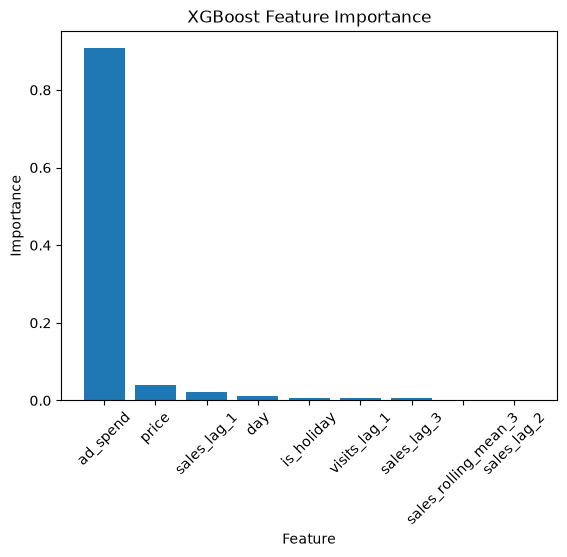

In [118]:
plt.bar(
    xgb_importance["feature"],
    xgb_importance["importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [119]:
next_day_X = pd.DataFrame({
    "day": [31],
    "price": [8],
    "ad_spend": [320],
    "is_holiday": [1],

    "sales_lag_1": [df["sales"].iloc[-1]],
    "sales_lag_2": [df["sales"].iloc[-2]],
    "sales_lag_3": [df["sales"].iloc[-3]],

    "visits_lag_1": [df["visits"].iloc[-1]],

    "sales_rolling_mean_3": [df["sales"].iloc[-3:].mean()]
})

next_day_X

,day,price,ad_spend,is_holiday,sales_lag_1,sales_lag_2,sales_lag_3,visits_lag_1,sales_rolling_mean_3
0,31,8,320,1,260,245,210,2100,238.333333


In [120]:
next_day_pred = xgb_model.predict(next_day_X)

print("XGBoost 预测第 31 天销量：", next_day_pred[0])

XGBoost 预测第 31 天销量： 213.71391
